# Titanic 2: Decision Trees



### Pros, Cons, How It Works, and a Visual:

#### Pros:
- **Helpful for feature selection**: Can tell us which features are most important for differentiating target classes. We'll see in a future lesson why this can be so helpful 🧩.
- **"White box"**: We can see and understand exactly how a decision tree works. This allows us to use the model to better understand the problem (e.g. what was responsible for people surviving or dying the crash. This is called "explanatory modeling") and also allows us to evaluate whether the model is making its predictions in ways that are ethical and legal 🔍.
- **Does automatic feature selection**: Ignores features that don't help predict the label. This reduces the amount of preprocessing required ⚙️.

#### Cons:
- **Struggles with**: Datasets that have a lot of predictor features, extrapolating with regression tasks (e.g. can't predict a price higher than those in the training data), capturing simple linear relationships with regression tasks. Decision trees are also very prone to overfitting, making it difficult for them to detect nuanced patterns that are population-wide (recall the Bias-Variance tradeoff mentioned in the last notebook)

#### How it Works:
Remember that every algorithm has two phases: 1. The algorithm fits a model to the training data (this is where it comes up with a specific decision tree) 2. The model can then make predictions about new data (this is how it uses the fit decision tree). **Consult the visual below to help in understanding this explanation.**
- The goal of the algorithm is to sort the training data into groups that all have the same label. It does this by splitting the training data using the predictor features. For instance, by splitting the titanic data using the sex feature, we can sort it into one group of female passengers that mostly survived and another group of male passengers that mostly died (this dataset only has two sex options, but keep in mind modern datasets you will encounter may have more options).
- Sorting the training data like this indirectly captures patterns that can help us predict the labels of new data. Now if I have to predict what happened to a new female passenger, I know (assuming the training data are reflective of the overall population) that they are more likely to have survived.
- To construct a full decision tree, the algorithm repeats this process, splitting those groups further. For instance, we may split the male group into a young boys group that mostly survived and an adult men group that mostly died.
- By repeatedly splitting the data, the algorithm can sort the training data into groups (which we call "nodes") that are more and more "pure", purity being a measure of how similar the labels are of the training data in that group. In the titanic case, a node is maximally pure when the passengers in that group either all died or all survived.
- When a group is very large and very pure it will be a good predictor. In the titanic case, if a large group of passengers that share some set of characteristics all survived, it is statistically very likely that other passengers with those characteristics (even those that weren't in the training data) survived as well. For instance, if there are a lot of female first-class passengers in my training data and every one of them survived, I can be confident predicting that other passengers with those same characteristics also survived because statistically it is very likely that this is a reliable, population-wide pattern.
- In the end, after we've finished fitting the model to the training data, the tree will look like a series of questions we call "decision nodes" that ask about the characteristics of the passengers. These are the same questions we used to split the training data when sorting it to come up with the tree. At the end of each line of questioning, there will be a group of people in the training data that answered the questions the same way who should mostly share the same label (with a complex problem though, getting very pure groups may prove difficult, resulting in some groups that are still fairly mixed). These groups and the end of the lines of questioning are the "leaf nodes". To make a prediction with the tree, we ask the questions in the decision nodes to travel down the branches until we get to a leaf, and then predict the class that is most common among the training data in that leaf.

In summary, the algorithm, when fitting, sorts the training data into groups that are similarly classified and then, when making a prediction, looks at which group that new observation belongs in and predicts that it is of the same class.

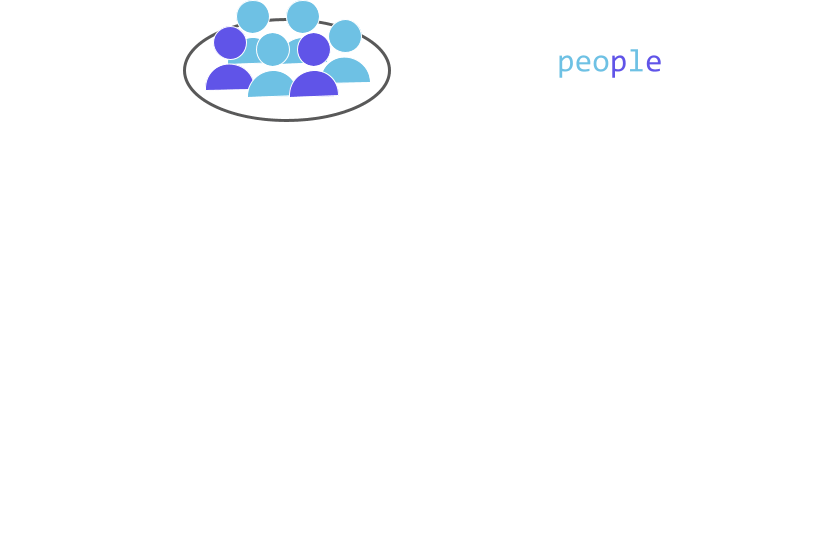

## 1. Read the data

**Dataset variables:**

*   survival -->	Whether a passenger survived or not
*   pclass -->	Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
*   sex -->	Sex
*   Age -->	Age in years
*   sibsp -->	# of siblings / spouses aboard the Titanic
*   parch -->	# of parents / children aboard the Titanic
*   ticket -->	Ticket number
*   fare -->	Passenger fare
*   cabin -->	Cabin number
*   embarked -->	Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [10]:
import pandas as pd

url = "https://drive.google.com/file/d/1g3uhw_y3tboRm2eYDPfUzXXsw8IOYDCy/view?usp=sharing"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


data = pd.read_csv(path)
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Define X and y

In [11]:
X = data.drop(columns=["PassengerId", "Name", "Ticket", "Sex", "Cabin", "Embarked"])
y = X.pop("Survived")

## 3. Data Splitting (Train - Test)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31416)

## 4. Implement a Decision Tree

A Decision Tree is one of the simplest Machine Learning models. To implement it, we need to first:

- Import it from the appropriate submodule of Scikit-Learn.
- Initialize it.
- Fit it.

In [13]:
# 1. import the model
from sklearn.tree import DecisionTreeClassifier

# 2. initialize the model (optional: give some parameters)
my_tree = DecisionTreeClassifier()

# 3. fit the model to the train data
my_tree.fit(X=X_train, y=y_train)

DecisionTreeClassifier()

**We got an error**: the model cannot deal with categorical features. We will soon learn to encode them as numbers, but our approach should always be to quickly complete the task  first, and iterate to improve it later. This is the reason why we will simply start by dropping the categorical features.

## 5. Select only numerical features


In [14]:
# another option: X_num = X.drop(columns=["Sex", "Cabin", "Embarked"])
X_num = X.select_dtypes(include="number")

In [15]:
X_num#.columns

,Pclass,Age,SibSp,Parch,Fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500
...,...,...,...,...,...
886,2,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,3,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000


### 5.1. Train-test split

Since we created a new dataframe without the categorical features, we need to create our test and train sets again.

In [16]:
X_num_train, X_num_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=123)

### 5.2. Implement a Decision Tree (numerical features)

In [17]:
# 1. import the model
from sklearn.tree import DecisionTreeClassifier

# 2. initialize the model (optional: give some parameters)
my_tree = DecisionTreeClassifier()

# 3. fit the model to the train data
my_tree.fit(X=X_num_train, y=y_train)

DecisionTreeClassifier()

Note: In the past this code would also have thrown an error because most models cannot handle missing values in the dataset. Sklearn has since updated its decision tree to be able to automatically handle missing values, but most other models would return an error. Lets look at what happens when we try to fit a different model, KNN, which we will learn more about in an upcoming lesson:

In [19]:
# import
from sklearn.neighbors import KNeighborsClassifier
# initialize
model = KNeighborsClassifier()
# fit
model.fit(X_num_train, y_train)

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 6. Dealing with missing data

For various reasons, many real world datasets contain missing values, often encoded as blanks, NaNs or other placeholders. Such datasets are incompatible with **most** scikit-learn estimators which assume that all values in an array are numerical, and that all have and hold meaning. **Most** machine learning algorithms require that their inputs have no missing values, and will not work if this requirement is violated.
For more details on estimators that handle NaN values in the new versions of SciKit-Learn, take a look here: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import sklearn
sklearn. __version__

A basic strategy in order to use incomplete datasets is to discard entire rows and/or columns containing missing values. However, this comes at the price of losing data which may be valuable (even though incomplete). A better strategy is to impute the missing values, i.e., to infer them from the known part of the data.
We will use the `SimpleImputer()` with its default values. It will replace any missing value with the mean of the column it belongs to.

Simple imputer allows these strategies:
- mean (default),
- median,
- most frequent,
- constant.

For more details, look here: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

In [ ]:
X_num_train.isna().sum()

In [ ]:
from sklearn.impute import SimpleImputer

Follow this approach for different types of estimators:
1. initialize,
2. use fit on the **train** set,
3. use transform on the **train** set,
4. use transform on the **test** set.

It is possible to combine steps 2 and 3 and use fit_transform instead.

The **.fit() method** is used to learn parameters from the training data. For example, an imputer learns statistical measures (like mean or median) from the training data to impute missing values.

The **.transform() method** applies the learned transformation (imputation, scaling, etc.) to new data. It does not learn anything new; it simply applies the transformations based on the parameters learned during .fit().

NO DATA SNOOPING! **Do not fit to both train, test and do not transform test before train data.**


In [ ]:
from sklearn import set_config
# this code will make it so that whenever we transform data the output is a data frame
set_config(transform_output='pandas')

In [ ]:
# 1. initialize
my_imputer = SimpleImputer()

In [ ]:
# 2. use fit on the train set
my_imputer.fit(X_num_train)

In [ ]:
# 3. use transform on the train set
X_num_imputed_train = my_imputer.transform(X_num_train)

In [ ]:
X_num_imputed_train.isnull().sum()

We will implement the 4th step in 7.1.

### 6.1. Implement a Decision Tree (numerical features + missing values imputed)

In [ ]:
# 1. import the model
from sklearn.tree import DecisionTreeClassifier

# 2. initialize the model (optional: give some parameters)
my_tree = DecisionTreeClassifier()

# 3. fit the model to the train data
my_tree.fit(X = X_num_imputed_train,
            y = y_train)

### 6.2. Make predictions and check accuracy on the train set

In [ ]:
# make predictions
y_pred_tree_train = my_tree.predict(X_num_imputed_train)

**.predict() method**: you pass in the input data (X_num_imputed_train) for which you want to predict the target variable (or class labels).


In [ ]:
# Check accuracy on the train set
from sklearn.metrics import accuracy_score

accuracy_score(y_true = y_train,
               y_pred = y_pred_tree_train
              )

The model seems to work REALLY well. Suspiciously well, even. Remember that the model has been trained using the train set and we have now checked its accuracy on the very same train set. The real evaluation will come from the test set.

## 7. Check accuracy for the test set

Is the model able to generalize? Is it able to make predictions on data it has not "seen" before?

### 7.1. Transform the test set

The test set already contains only numerical features, but we still need to impute the missing values with the "imputer" we already created and fitted on the train set.

Remember: transformers only have to be fitted to the train set. Then, they are used to transform both the train and the test set.

In [ ]:
# impute NaN's to test set
X_num_imputed_test = my_imputer.transform(X_num_test)

### 7.2. Make predictions on the test set

In [ ]:
y_pred_tree_test = my_tree.predict(X_num_imputed_test)

### 7.3. Check accuracy score on the test set

In [ ]:
accuracy_score(y_true = y_test,
               y_pred = y_pred_tree_test
              )

This accuracy is even lower than some of our intuition-based models...

Our model has a **very high variance**: the difference between train and test set is huge. We can also say that our model suffers from **overfitting**: it has captured patterns in the training set that were not present in the testing set (they were mere "noise").

We will need to improve the model.

## 8. Plotting the Decision Tree

A Decision Tree is a succession of rules that split the dataset based on the variables that better predict the target. This tree, with its rules, can be visualized in a diagram:

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(64, 32))

plot_tree(
    my_tree,                          # Decision tree model to visualize
    filled=True,                      # Whether to fill nodes with colors based on majority class
    rounded=True,                     # Whether to round the corners of the nodes
    class_names=['Not Survived','Survived'],  # Names of the classes for the target variable
    feature_names=X_num.columns       # Names of the features (columns) in your dataset
);


Our current tree is too big to distinguish what's going on. It has dozens, maybe hundreds of rules. In other words, our model is **very complex**, which is a common characteristic of models that suffer from overfitting.

To reduce the complexity (the size) of the tree and prevent overfitting, we can play with the hyperparameters of the tree. It's a process known as "pruning" the tree.

### **Exercise 1**: Pruning the tree

1. Tweak the parameters `max_depth` and `min_samples_leaf` of the decision tree, based on the Scikit-Learn documentation and the Statquest videos you watched following the Learning Platform.
2. Try to make the tree smaller.
3. Visualize the new tree.
4. Check the performance of your "small tree" on the train & test sets.

Major Hyperparameters:

- `max_depth`: Limits how many follow-up questions the tree can ask. The more questions we ask, the more specific the groups are that we are making predictions with (the leaf nodes) which makes them less likely to represent general, population-wide patterns. Lower numbers will prevent overfitting but may lead to underfitting. A range of **2-15** is reasonable depending on the complexity of the problem and the number of features in the dataset. It can be much larger though if the problem is highly complex and we have a lot of training data.
- `min_samples_leaf`: Limits how small the leaf nodes can be. Remember that the algorithm is finding groups of training data that all (or mostly) have the same class so it can make predictions based on which group a new observation falls in. `min_samples_leaf` sets a limit on how small those groups can be. Higher numbers require to model to predict based on larger groups and can reduce overfitting. We can provide a specific number of observations with an integer or a proportion of the dataset with a float, which can be helpful if we are fitting the model to differently sized datasets at various points in the process (tomorrow you will see when and why we do this). The right number depends on the complexity of the problem, more complex problems requiring smaller groups/leaves, but a range between 0.01 and 0.1 is a good place to start.<br>

Later we will provide you with a cheatsheet with more extensive coverage of the different hyperparameters worth adjusting and reasonable ranges to start with.

In [ ]:
# your code here

## **Your challenge**

In a new notebook, apply everything you have learned here to the Housing project.